 ## Section 1: Data Understanding & Preparation

In [35]:
import pandas as pd

df = pd.read_csv("../data/TelcoCustomerChurn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [36]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [37]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [38]:
df.duplicated().sum()

np.int64(0)

### Duplicate check

The duplicate check returned **0**, so every customer record is unique and no deduplication is required.

In [39]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].isnull().sum()

np.int64(11)

In [40]:
df[df['TotalCharges'].isnull()][['tenure']]


,tenure
488,0
753,0
936,0
1082,0
1340,0
3331,0
3826,0
4380,0
5218,0
6670,0


In [41]:
df['TotalCharges'] = df['TotalCharges'].fillna(0)
df['TotalCharges'].isnull().sum()

np.int64(0)

### Handling missing `TotalCharges` values

`TotalCharges` was stored as text and contained blank values for **11 customers**. Converting the column to a numeric type exposed those blanks as `NaN`. All 11 affected customers had a `tenure` of 0, showing that they were brand-new customers with no billing history rather than invalid records. Their missing values were therefore filled with 0 instead of dropping the rows, because a total charge of 0 is mathematically correct for a customer who has not paid anything yet.

In [42]:
df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object

### Column roles

- **Numerical features:** `tenure`, `MonthlyCharges`, and `TotalCharges`.
- **Categorical features:** `gender`, `SeniorCitizen` (a binary indicator stored as 0/1), `Partner`, `Dependents`, `PhoneService`, `MultipleLines`, `InternetService`, `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`, `Contract`, `PaperlessBilling`, and `PaymentMethod`.
- **Target:** `Churn`.
- **Identifier:** `customerID` is dropped before modelling because it uniquely identifies a customer but has no predictive meaning.

In [43]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

### Target distribution

The target is imbalanced: approximately **73.5%** of customers did not churn and **26.5%** did. This means accuracy alone could be misleading because a model can achieve a high accuracy by favouring the majority class. Recall for the churn class is especially important: failing to identify a real churner is generally more costly than incorrectly flagging a customer who would have stayed.

In [44]:
for col in df.select_dtypes(include='object').columns:
    print(col, df[col].unique())

customerID <StringArray>
['7590-VHVEG', '5575-GNVDE', '3668-QPYBK', '7795-CFOCW', '9237-HQITU',
 '9305-CDSKC', '1452-KIOVK', '6713-OKOMC', '7892-POOKP', '6388-TABGU',
 ...
 '9767-FFLEM', '0639-TSIQW', '8456-QDAVC', '7750-EYXWZ', '2569-WGERO',
 '6840-RESVB', '2234-XADUH', '4801-JZAZL', '8361-LTMKD', '3186-AJIEK']
Length: 7043, dtype: str
gender <StringArray>
['Female', 'Male']
Length: 2, dtype: str
Partner <StringArray>
['Yes', 'No']
Length: 2, dtype: str
Dependents <StringArray>
['No', 'Yes']
Length: 2, dtype: str
PhoneService <StringArray>
['No', 'Yes']
Length: 2, dtype: str
MultipleLines <StringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str
InternetService <StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str
OnlineSecurity <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
OnlineBackup <StringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str
DeviceProtection <StringArray>
['No', 'Yes', 'No internet service']
Length: 3,

C:\Users\Kumar Hanish\AppData\Local\Temp\ipykernel_39148\3255506791.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:


In [45]:
for col in ['OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies']:
    print(col, df[col].unique())

OnlineSecurity <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
OnlineBackup <StringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str
DeviceProtection <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
TechSupport <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
StreamingTV <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
StreamingMovies <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str


In [46]:
cols_to_clean = ['MultipleLines','OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies']
for col in cols_to_clean:
    df[col] = df[col].replace({'No phone service': 'No', 'No internet service': 'No'})

### Consolidating service categories

The values `No phone service` and `No internet service` repeat information already captured by the `PhoneService` and `InternetService` columns. They were consolidated into `No` to remove redundant categories and avoid unnecessary encoding noise.

In [47]:
for col in cols_to_clean:
    print(col, df[col].unique())

MultipleLines <StringArray>
['No', 'Yes']
Length: 2, dtype: str
OnlineSecurity <StringArray>
['No', 'Yes']
Length: 2, dtype: str
OnlineBackup <StringArray>
['Yes', 'No']
Length: 2, dtype: str
DeviceProtection <StringArray>
['No', 'Yes']
Length: 2, dtype: str
TechSupport <StringArray>
['No', 'Yes']
Length: 2, dtype: str
StreamingTV <StringArray>
['No', 'Yes']
Length: 2, dtype: str
StreamingMovies <StringArray>
['No', 'Yes']
Length: 2, dtype: str


In [48]:
df = df.drop('customerID', axis=1)

binary_cols = ['gender','Partner','Dependents','PhoneService','PaperlessBilling',
               'MultipleLines','OnlineSecurity','OnlineBackup','DeviceProtection',
               'TechSupport','StreamingTV','StreamingMovies','Churn']

for col in binary_cols:
    df[col] = df[col].map({col_val: i for i, col_val in enumerate(sorted(df[col].unique()))})

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,0,DSL,0,1,0,0,0,0,Month-to-month,1,Electronic check,29.85,29.85,0
1,1,0,0,0,34,1,0,DSL,1,0,1,0,0,0,One year,0,Mailed check,56.95,1889.50,0
2,1,0,0,0,2,1,0,DSL,1,1,0,0,0,0,Month-to-month,1,Mailed check,53.85,108.15,1
3,1,0,0,0,45,0,0,DSL,1,0,1,1,0,0,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,0,0,0,0,2,1,0,Fiber optic,0,0,0,0,0,0,Month-to-month,1,Electronic check,70.70,151.65,1


In [49]:
df = pd.get_dummies(df, columns=['InternetService','Contract','PaymentMethod'], drop_first=True)
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,MonthlyCharges,TotalCharges,Churn,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,0,0,1,0,...,29.85,29.85,0,False,False,False,False,False,True,False
1,1,0,0,0,34,1,0,1,0,1,...,56.95,1889.50,0,False,False,True,False,False,False,True
2,1,0,0,0,2,1,0,1,1,0,...,53.85,108.15,1,False,False,False,False,False,False,True
3,1,0,0,0,45,0,0,1,0,1,...,42.30,1840.75,0,False,False,True,False,False,False,False
4,0,0,0,0,2,1,0,0,0,0,...,70.70,151.65,1,True,False,False,False,False,True,False


### Encoding categorical variables

Binary categorical columns were mapped directly to 0 and 1. The multi-category columns `InternetService`, `Contract`, and `PaymentMethod` were one-hot encoded. Using `drop_first=True` removes one reference category from each group, avoiding redundant dummy variables and reducing multicollinearity.

In [50]:
df = df.astype({col: int for col in df.select_dtypes(include='bool').columns})
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,MonthlyCharges,TotalCharges,Churn,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,0,0,1,0,...,29.85,29.85,0,0,0,0,0,0,1,0
1,1,0,0,0,34,1,0,1,0,1,...,56.95,1889.50,0,0,0,1,0,0,0,1
2,1,0,0,0,2,1,0,1,1,0,...,53.85,108.15,1,0,0,0,0,0,0,1
3,1,0,0,0,45,0,0,1,0,1,...,42.30,1840.75,0,0,0,1,0,0,0,0
4,0,0,0,0,2,1,0,0,0,0,...,70.70,151.65,1,1,0,0,0,0,1,0


In [51]:
from sklearn.model_selection import train_test_split

X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(X_train.shape, X_test.shape)

(4930, 23) (2113, 23)


In [52]:
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

Churn
0    0.734686
1    0.265314
Name: proportion, dtype: float64
Churn
0    0.734501
1    0.265499
Name: proportion, dtype: float64


## Section 2: Exploratory Data Analysis

In [53]:
df_eda = pd.read_csv("../data/TelcoCustomerChurn.csv")
df_eda['TotalCharges'] = pd.to_numeric(df_eda['TotalCharges'], errors='coerce').fillna(0)

cols_to_clean = ['MultipleLines','OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies']
for col in cols_to_clean:
    df_eda[col] = df_eda[col].replace({'No phone service': 'No', 'No internet service': 'No'})

df_eda.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


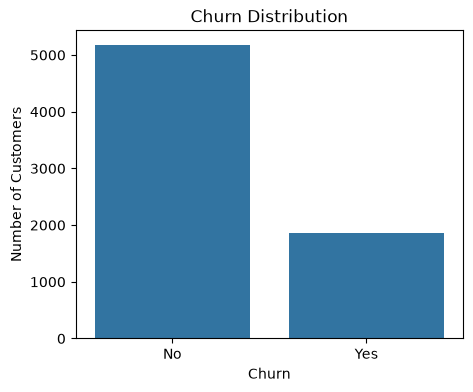

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(5,4))
sns.countplot(data=df_eda, x='Churn')
plt.title('Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')
plt.show()

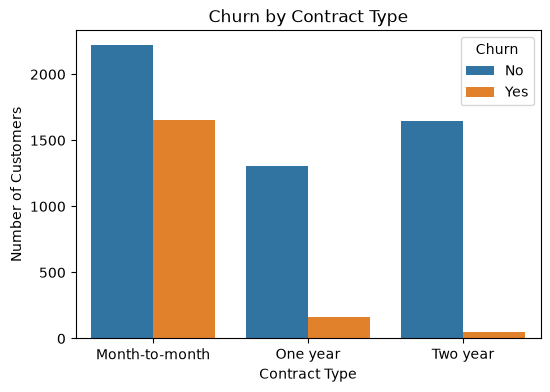

In [55]:
plt.figure(figsize=(6,4))
sns.countplot(data=df_eda, x='Contract', hue='Churn')
plt.title('Churn by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Number of Customers')
plt.show()

Contract type is one of the strongest churn drivers. Month-to-month customers churn at a much higher rate than those on one- or two-year contracts, likely because longer contracts come with switching costs/commitments. This suggests incentivizing longer contracts (discounts, loyalty perks) could meaningfully reduce churn.

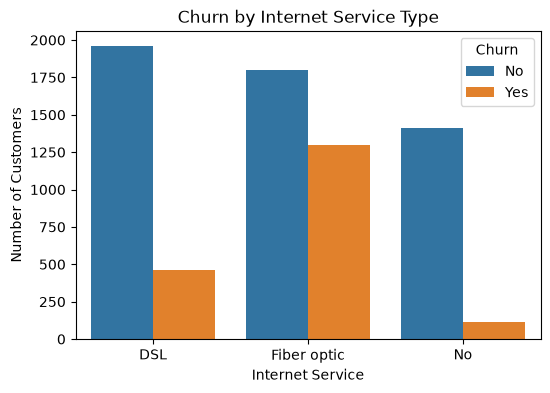

In [56]:
plt.figure(figsize=(6,4))
sns.countplot(data=df_eda, x='InternetService', hue='Churn')
plt.title('Churn by Internet Service Type')
plt.xlabel('Internet Service')
plt.ylabel('Number of Customers')
plt.show()

Fiber optic customers churn at a much higher rate than DSL customers, despite fiber typically being the premium/faster service. This could point to pricing dissatisfaction, service reliability issues, or stronger competitor offers specifically in the fiber segment - worth investigating further as a targeted retention priority.

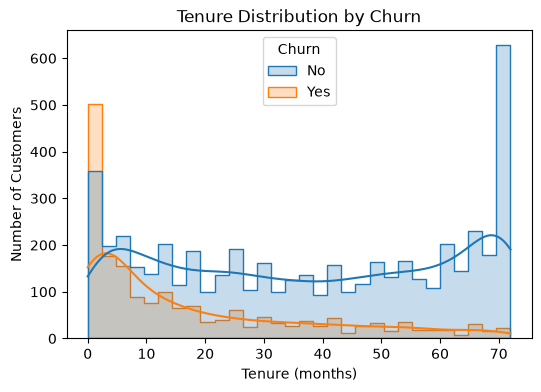

In [57]:
plt.figure(figsize=(6,4))
sns.histplot(data=df_eda, x='tenure', hue='Churn', bins=30, kde=True, element='step')
plt.title('Tenure Distribution by Churn')
plt.xlabel('Tenure (months)')
plt.ylabel('Number of Customers')
plt.show()

Insight: Churn is highest among new customers and declines steadily as tenure increases. Customers who stay past roughly the first year become significantly less likely to churn. This suggests the first few months are the highest-risk window - onboarding experience and early engagement likely have an outsized impact on retention.

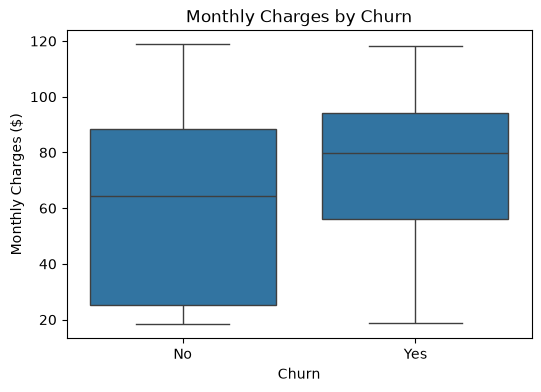

In [58]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df_eda, x='Churn', y='MonthlyCharges')
plt.title('Monthly Charges by Churn')
plt.xlabel('Churn')
plt.ylabel('Monthly Charges ($)')
plt.show()

Insight: Customers who churn tend to pay higher monthly charges. Combined with the earlier finding that fiber optic (the pricier service) has higher churn, this suggests price sensitivity is a meaningful factor - customers on higher-cost plans may feel they aren't getting proportional value, making them prime candidates for retention offers or plan-value conversations.

## Section 3: Feature Engineering

In [59]:
service_cols = ['OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies']

X_train['TotalServices'] = X_train[service_cols].sum(axis=1)
X_test['TotalServices'] = X_test[service_cols].sum(axis=1)

X_train[['TotalServices']].value_counts().sort_index()

TotalServices
0                1538
1                 658
2                 733
3                 773
4                 612
5                 399
6                 217
Name: count, dtype: int64

Feature 1 - TotalServices: Sum of 6 add-on service flags (OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies) into a single count from 0–6. Customers using more add-on services are more embedded in the ecosystem and likely to be stickier, so this condenses 6 sparse binary columns into one meaningful engagement score.

In [60]:
bins = [-1, 12, 24, 48, 72]
labels = ['0-1yr', '1-2yr', '2-4yr', '4-6yr']

X_train['TenureGroup'] = pd.cut(X_train['tenure'], bins=bins, labels=labels)
X_test['TenureGroup'] = pd.cut(X_test['tenure'], bins=bins, labels=labels)

X_train['TenureGroup'].value_counts().sort_index()

TenureGroup
0-1yr    1537
1-2yr     707
2-4yr    1118
4-6yr    1568
Name: count, dtype: int64

In [61]:
X_train = pd.get_dummies(X_train, columns=['TenureGroup'], drop_first=True)
X_test = pd.get_dummies(X_test, columns=['TenureGroup'], drop_first=True)

X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

X_train = X_train.astype({col: int for col in X_train.select_dtypes(include='bool').columns})
X_test = X_test.astype({col: int for col in X_test.select_dtypes(include='bool').columns})

X_train.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,TotalServices,TenureGroup_1-2yr,TenureGroup_2-4yr,TenureGroup_4-6yr
5557,0,0,0,0,5,1,0,0,0,0,...,0,0,0,0,1,0,1,0,0,0
2270,0,1,0,0,3,1,0,0,0,1,...,0,0,0,0,1,0,2,0,0,0
6930,0,0,1,0,3,1,1,0,0,0,...,0,0,0,1,0,0,0,0,0,0
2257,0,0,0,0,60,1,1,0,0,1,...,0,1,0,1,0,0,4,0,0,1
898,0,0,0,0,12,1,0,1,0,0,...,0,0,0,0,0,0,4,0,0,0


Feature 2 - TenureGroup: Bucketed tenure into 4 ranges (0-1yr, 1-2yr, 2-4yr, 4-6yr) and one-hot encoded them. The EDA showed churn risk drops sharply in the first year then flattens - a tenure "risk tier" like this lets the Decision Tree split directly on that non-linear pattern rather than relying on many small threshold splits on the raw tenure number.

## Section 4: Model Training - Decision Tree Classifier

In [62]:
from sklearn.tree import DecisionTreeClassifier

dt1 = DecisionTreeClassifier(random_state=42)
dt1.fit(X_train, y_train)

train_acc = dt1.score(X_train, y_train)
test_acc = dt1.score(X_test, y_test)
print("Train accuracy:", train_acc)
print("Test accuracy:", test_acc)

Train accuracy: 0.9979716024340771
Test accuracy: 0.7302413629910081


Configuration 1 - Default (unrestricted) Decision Tree: Train accuracy 99.8%, test accuracy 73.0%. The huge gap between train and test indicates severe overfitting - the tree grew deep enough to memorize training examples rather than learning generalizable patterns.

In [63]:
dt2 = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=20,
    min_samples_leaf=10,
    class_weight='balanced',
    random_state=42
)
dt2.fit(X_train, y_train)

train_acc2 = dt2.score(X_train, y_train)
test_acc2 = dt2.score(X_test, y_test)
print("Train accuracy:", train_acc2)
print("Test accuracy:", test_acc2)

Train accuracy: 0.7350912778904666
Test accuracy: 0.7165168007572172


Configuration 2 - Constrained Decision Tree: max_depth=5, min_samples_split=20, min_samples_leaf=10, class_weight='balanced'. Train accuracy 73.5%, test accuracy 71.6% - a gap of only ~2 points versus Configuration 1's ~27-point gap, indicating the model now generalizes well instead of overfitting. Overall accuracy is slightly lower than Configuration 1's, but this is expected: class_weight='balanced' prioritizes correctly identifying churners (the minority class) over raw accuracy, which better aligns with the business goal of catching at-risk customers.

Final choice: Configuration 2. Despite marginally lower accuracy, it is the better model - it generalizes to unseen customers rather than memorizing training data, and it doesn't ignore the minority churn class the way an accuracy-optimized model naturally would.

## Section 5: Model Evaluation

In [64]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

y_pred = dt2.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.7165168007572172
Precision: 0.47925764192139736
Recall: 0.7825311942959001
F1 Score: 0.5944482058226134

Confusion Matrix:
 [[1075  477]
 [ 122  439]]

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.69      0.78      1552
           1       0.48      0.78      0.59       561

    accuracy                           0.72      2113
   macro avg       0.69      0.74      0.69      2113
weighted avg       0.79      0.72      0.73      2113



Evaluation results: Accuracy 71.6%, Precision 47.9%, Recall 78.3%, F1 0.59.

Business interpretation: Of the 561 customers who actually churned in the test set, the model correctly identified 439 of them (78% recall) - meaning the business would be alerted to the large majority of at-risk customers in time to act. The trade-off is precision: only 48% of customers flagged as "at risk" actually churn, so roughly half of retention outreach (calls, discount offers) would go to customers who weren't actually going to leave.

Precision vs. Recall justification: In this business context, recall matters more than precision. A false negative (a churner the model misses) means losing that customer's revenue entirely, with no chance to intervene. A false positive (a loyal customer wrongly flagged) only costs an unnecessary retention offer or discount - a much smaller loss. Given this cost asymmetry, it's better to over-flag and occasionally waste a retention offer than to under-flag and silently lose paying customers. This is why class_weight='balanced' was deliberately used in Configuration 2, even though it slightly reduced overall accuracy.

## Section 6: Model Interpretation

In [65]:
import numpy as np

importances = pd.Series(dt2.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print(importances.head(10))

Contract_Two year                 0.395548
Contract_One year                 0.256118
InternetService_Fiber optic       0.103897
tenure                            0.097016
InternetService_No                0.030535
StreamingMovies                   0.030214
TotalCharges                      0.027395
MonthlyCharges                    0.020280
PaymentMethod_Electronic check    0.019410
gender                            0.006275
dtype: float64


Feature importance: Contract type dominates the model's decisions - Contract_Two year (39.6%) and Contract_One year (25.6%) together account for ~65% of total importance, confirming the EDA finding that contract length is the single strongest churn driver. InternetService_Fiber optic (10.4%) and tenure (9.7%) are the next most influential features, also matching earlier visual findings. Notably, neither engineered feature (TotalServices, TenureGroup) ranks in the top 10 - contract type and tenure already captured most of that signal, but they still add marginal value and are worth keeping as they may matter more in a differently-tuned model.

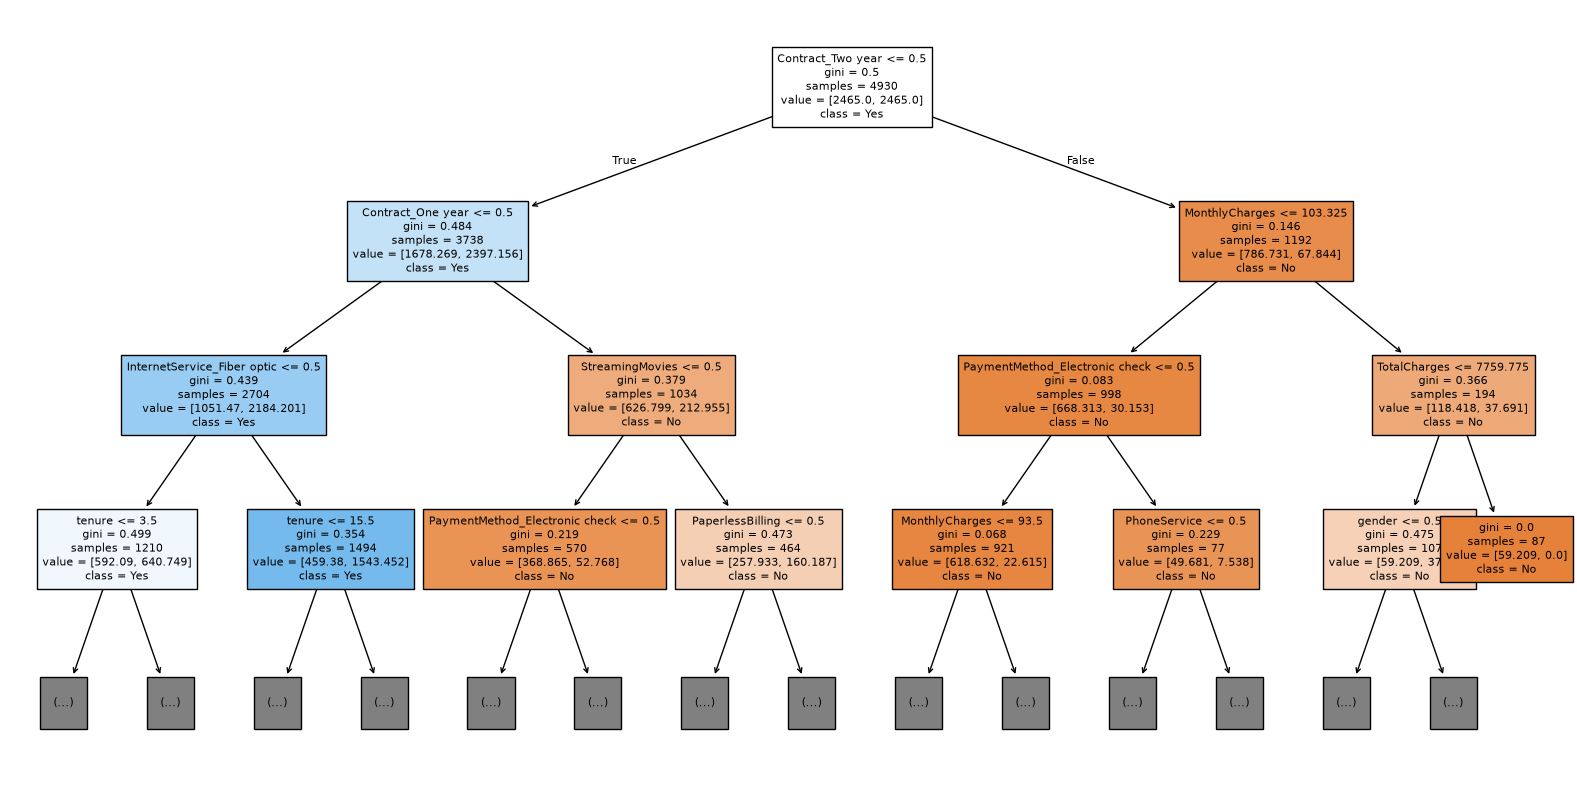

In [66]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))
plot_tree(dt2, feature_names=X_train.columns, class_names=['No','Yes'], filled=True, max_depth=3, fontsize=8)
plt.show()

Tree visualization interpretation: The root split is Contract_Two year, meaning the model's very first decision separates two-year contract customers (much lower baseline churn risk) from everyone else. Within the higher-risk group, the next split is Contract_One year, further separating month-to-month customers (highest risk) from one-year contract customers. On the month-to-month branch, InternetService_Fiber optic becomes the deciding factor, showing that within the highest-risk contract group, fiber customers are flagged as even more likely to churn. This mirrors the EDA findings exactly: contract length is the dominant risk factor, with internet service type as a secondary but meaningful factor.

## Section 7: Save Model & Build API

In [67]:
import joblib

joblib.dump(dt2, '../model/churn_model.pkl')
joblib.dump(list(X_train.columns), '../model/model_columns.pkl')

['../model/model_columns.pkl']